# Random Forest Classification

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [25]:
dataset = pd.read_csv('Data.csv')
X = dataset.iloc[:, 1:-1].values
y = dataset.iloc[:, -1].values

In [26]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25)

In [27]:
print(X_train)

[[1 0 2 ... 'Yes' 'Yes' 'Not sure']
 [0 1 1 ... 'Not sure' 'Yes' 'Yes']
 [1 1 2 ... 'Yes' 'Yes' 'No']
 ...
 [1 2 1 ... 'Yes' 'Yes' 'Yes']
 [1 1 2 ... 'Not sure' 'Yes' 'Not sure']
 [1 0 2 ... 'Yes' 'Yes' 'Yes']]


In [28]:
print(y_train)

['Engineer' 'Engineer' 'Engineer' 'Engineer' 'Engineer'
 'Business Related Profession' 'Business Related Profession' 'Engineer'
 'Business Related Profession' 'Doctor' 'Engineer' 'Engineer' 'Engineer'
 'Engineer' 'Doctor' 'Engineer' 'Engineer' 'Engineer' 'Doctor'
 'Business Related Profession' 'Engineer' 'Doctor' 'Engineer'
 'Business Related Profession' 'Doctor' 'Business Related Profession'
 'Doctor' 'Engineer' 'Engineer' 'Business Related Profession' 'Engineer'
 'Doctor' 'Doctor' 'Engineer' 'Engineer' 'Engineer' 'Engineer' 'Engineer'
 'Doctor' 'Business Related Profession' 'Business Related Profession'
 'Business Related Profession' 'Doctor' 'Engineer' 'Engineer'
 'Business Related Profession' 'Engineer' 'Doctor'
 'Business Related Profession' 'Business Related Profession' 'Engineer'
 'Engineer' 'Engineer' 'Engineer' 'Doctor' 'Engineer'
 'Business Related Profession' 'Engineer' 'Engineer' 'Engineer' 'Engineer'
 'Engineer' 'Doctor' 'Business Related Profession' 'Engineer' 'Doctor'
 '

In [29]:
print(X_test)

[[1 1 1 ... 'No' 'Yes' 'Yes']
 [2 1 1 ... 'No' 'Yes' 'Yes']
 [2 1 1 ... 'Yes' 'No' 'Yes']
 ...
 [2 2 2 ... 'No' 'No' 'No']
 [1 2 2 ... 'Yes' 'No' 'Yes']
 [2 2 2 ... 'No' 'No' 'No']]


In [30]:
print(y_test)

['Engineer' 'Engineer' 'Engineer' 'Doctor' 'Engineer' 'Engineer'
 'Business Related Profession' 'Engineer' 'Engineer' 'Engineer' 'Doctor'
 'Engineer' 'Engineer' 'Engineer' 'Doctor' 'Engineer' 'Engineer'
 'Engineer' 'Engineer' 'Engineer' 'Engineer' 'Engineer' 'Engineer'
 'Engineer' 'Engineer' 'Doctor' 'Doctor' 'Business Related Profession'
 'Business Related Profession' 'Doctor' 'Engineer' 'Engineer' 'Engineer'
 'Doctor' 'Doctor' 'Doctor' 'Engineer' 'Engineer' 'Engineer' 'Engineer'
 'Engineer' 'Engineer' 'Engineer' 'Business Related Profession'
 'Business Related Profession' 'Engineer' 'Business Related Profession'
 'Business Related Profession' 'Engineer' 'Engineer'
 'Business Related Profession' 'Engineer' 'Doctor' 'Engineer'
 'Business Related Profession' 'Business Related Profession' 'Engineer'
 'Doctor' 'Doctor' 'Engineer' 'Engineer' 'Doctor' 'Engineer'
 'Business Related Profession' 'Engineer' 'Doctor'
 'Business Related Profession' 'Business Related Profession' 'Doctor'
 'Doctor'

In [31]:
from sklearn.preprocessing import OrdinalEncoder
ord_enc = OrdinalEncoder()

X_train = ord_enc.fit_transform(X_train)

X_test = ord_enc.fit_transform(X_test)

In [32]:
print(X_train)

[[1. 0. 2. ... 2. 2. 1.]
 [0. 1. 1. ... 1. 2. 2.]
 [1. 1. 2. ... 2. 2. 0.]
 ...
 [1. 2. 1. ... 2. 2. 2.]
 [1. 1. 2. ... 1. 2. 1.]
 [1. 0. 2. ... 2. 2. 2.]]


In [33]:
print(X_test)

[[1. 1. 1. ... 0. 2. 2.]
 [2. 1. 1. ... 0. 2. 2.]
 [2. 1. 1. ... 2. 0. 2.]
 ...
 [2. 2. 2. ... 0. 0. 0.]
 [1. 2. 2. ... 2. 0. 2.]
 [2. 2. 2. ... 0. 0. 0.]]


In [34]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [35]:
print(X_train)

[[-0.32242815 -1.68724275  0.70417628 ...  1.10886517  0.84579773
  -0.11071058]
 [-2.19741791 -0.30489226 -0.9627897  ...  0.03219935  0.84579773
   1.14950562]
 [-0.32242815 -0.30489226  0.70417628 ...  1.10886517  0.84579773
  -1.37092679]
 ...
 [-0.32242815  1.07745823 -0.9627897  ...  1.10886517  0.84579773
   1.14950562]
 [-0.32242815 -0.30489226  0.70417628 ...  0.03219935  0.84579773
  -0.11071058]
 [-0.32242815 -1.68724275  0.70417628 ...  1.10886517  0.84579773
   1.14950562]]


In [36]:
print(X_test)

[[-0.32242815 -0.30489226 -0.9627897  ... -1.04446646  0.84579773
   1.14950562]
 [ 1.55256162 -0.30489226 -0.9627897  ... -1.04446646  0.84579773
   1.14950562]
 [ 1.55256162 -0.30489226 -0.9627897  ...  1.10886517 -1.84766527
   1.14950562]
 ...
 [ 1.55256162  1.07745823  0.70417628 ... -1.04446646 -1.84766527
  -1.37092679]
 [-0.32242815  1.07745823  0.70417628 ...  1.10886517 -1.84766527
   1.14950562]
 [ 1.55256162  1.07745823  0.70417628 ... -1.04446646 -1.84766527
  -1.37092679]]


In [37]:
from sklearn.ensemble import RandomForestClassifier
classifier = RandomForestClassifier(n_estimators = 10, criterion = 'entropy', random_state = 0)
classifier.fit(X_train, y_train)

RandomForestClassifier(criterion='entropy', n_estimators=10, random_state=0)

In [38]:
y_pred = classifier.predict(X_test)
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1)),1))

[['Engineer' 'Engineer']
 ['Engineer' 'Engineer']
 ['Engineer' 'Engineer']
 ['Doctor' 'Doctor']
 ['Engineer' 'Engineer']
 ['Engineer' 'Engineer']
 ['Engineer' 'Business Related Profession']
 ['Engineer' 'Engineer']
 ['Engineer' 'Engineer']
 ['Engineer' 'Engineer']
 ['Doctor' 'Doctor']
 ['Engineer' 'Engineer']
 ['Engineer' 'Engineer']
 ['Engineer' 'Engineer']
 ['Doctor' 'Doctor']
 ['Engineer' 'Engineer']
 ['Business Related Profession' 'Engineer']
 ['Engineer' 'Engineer']
 ['Engineer' 'Engineer']
 ['Engineer' 'Engineer']
 ['Engineer' 'Engineer']
 ['Engineer' 'Engineer']
 ['Engineer' 'Engineer']
 ['Engineer' 'Engineer']
 ['Engineer' 'Engineer']
 ['Doctor' 'Doctor']
 ['Doctor' 'Doctor']
 ['Business Related Profession' 'Business Related Profession']
 ['Business Related Profession' 'Business Related Profession']
 ['Doctor' 'Doctor']
 ['Engineer' 'Engineer']
 ['Engineer' 'Engineer']
 ['Engineer' 'Engineer']
 ['Doctor' 'Doctor']
 ['Engineer' 'Doctor']
 ['Doctor' 'Doctor']
 ['Engineer' 'Engine

In [39]:
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred, labels=classifier.classes_)
print(cm)
accuracy_score(y_test, y_pred)

[[ 28   0   2]
 [  0  34   6]
 [  4   0 105]]


0.9329608938547486

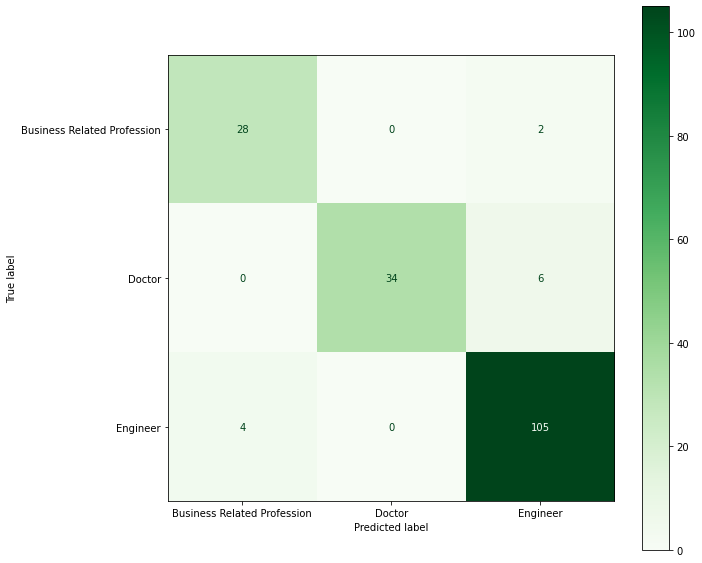

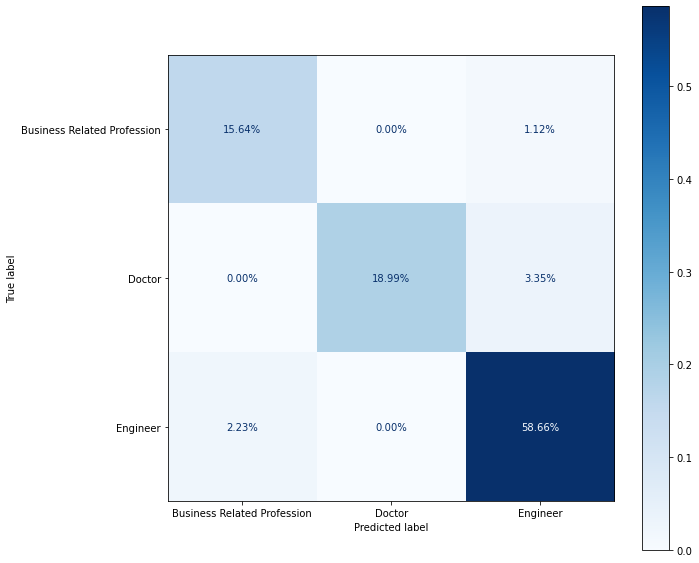

In [40]:
displ = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classifier.classes_)
_, ax = plt.subplots(figsize=(10,10))
displ.plot(cmap="Greens", ax=ax)
plt.show()
displ = ConfusionMatrixDisplay(confusion_matrix=cm/np.sum(cm), display_labels=classifier.classes_)
_, ax = plt.subplots(figsize=(10,10))
displ.plot(cmap="Blues", values_format='.2%', ax=ax)
plt.show()

In [41]:
#define metrics
from sklearn import metrics
y_pred_proba = classifier.predict_proba(X_test)[:,1]
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred_proba)

#create ROC curve
plt.plot(fpr,tpr)
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

ValueError: multiclass format is not supported